# Daily Overview

## Overview of the daily health stats

In [6]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import sys, os
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(project_root)

In [2]:
# The data
con = sqlite3.connect(r"C:\Users\Dexta\Learning\Garmin-Analysis\garminData\garmin.db")

dailySummary_raw = pd.read_sql(
    "SELECT * FROM DailySummary",
    con
)

dailySummary_raw.head()

sleep_raw = pd.read_sql(
    "SELECT * FROM Sleep",
    con
)

In [3]:
dailySummary_raw.describe()


,activeKilocalories,bmrKilocalories,totalSteps,totalDistanceMeters,highlyActiveSeconds,activeSeconds,moderateIntensityMinutes,vigorousIntensityMinutes,minHeartRate,maxHeartRate,...,charged,drained,endBattery,minBattery,maxBattery,averageStressLevel,maxStressLevel,lowStressDuration,mediumStressDuration,highStressDuration
count,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1290.000000,1290.000000,...,1290.000000,1290.000000,1287.000000,1290.000000,1290.000000,1290.000000,1290.000000,1290.000000,1290.000000,1288.000000
mean,849.385385,2107.551538,13936.309231,14472.744615,4315.410769,5588.853846,13.737692,15.265385,40.402326,155.667442,...,71.218605,74.523256,19.145299,13.434884,89.540310,45.476744,95.928682,11669.813953,9585.395349,6099.736025
std,422.838700,43.192424,5485.426762,6178.755305,1900.843700,3005.045458,17.051016,21.895114,2.355554,27.568215,...,18.724253,13.253212,10.328953,7.015943,13.276156,9.198518,2.366274,4021.957128,3482.894212,3726.899417
min,8.000000,898.000000,228.000000,184.000000,208.000000,102.000000,0.000000,0.000000,30.000000,84.000000,...,0.000000,0.000000,5.000000,5.000000,5.000000,12.000000,72.000000,420.000000,240.000000,540.000000
25%,534.500000,2098.000000,10184.250000,9951.750000,3034.250000,3347.000000,0.000000,0.000000,39.000000,145.250000,...,67.000000,68.000000,11.000000,7.250000,84.000000,39.000000,95.000000,8820.000000,7095.000000,3360.000000
50%,908.000000,2110.000000,14526.000000,15582.000000,4577.000000,5462.500000,8.000000,2.500000,40.000000,163.000000,...,75.000000,77.000000,18.000000,13.000000,94.000000,45.000000,96.000000,11520.000000,9180.000000,5160.000000
75%,1136.250000,2116.000000,17580.500000,18694.000000,5602.500000,7361.000000,22.000000,25.000000,42.000000,175.000000,...,82.000000,84.000000,26.000000,18.000000,99.000000,51.000000,98.000000,14205.000000,11745.000000,7920.000000
max,2199.000000,2637.000000,40214.000000,41257.000000,11342.000000,20883.000000,175.000000,111.000000,52.000000,202.000000,...,119.000000,108.000000,63.000000,63.000000,100.000000,79.000000,100.000000,26820.000000,23040.000000,24600.000000


## Heatmap of correlations

Much easier to see the strength of correlations via a heatmap.

What are the obvious correlations in my daily stats?
Are there any hidden or less obvious correlations I might have not considered?

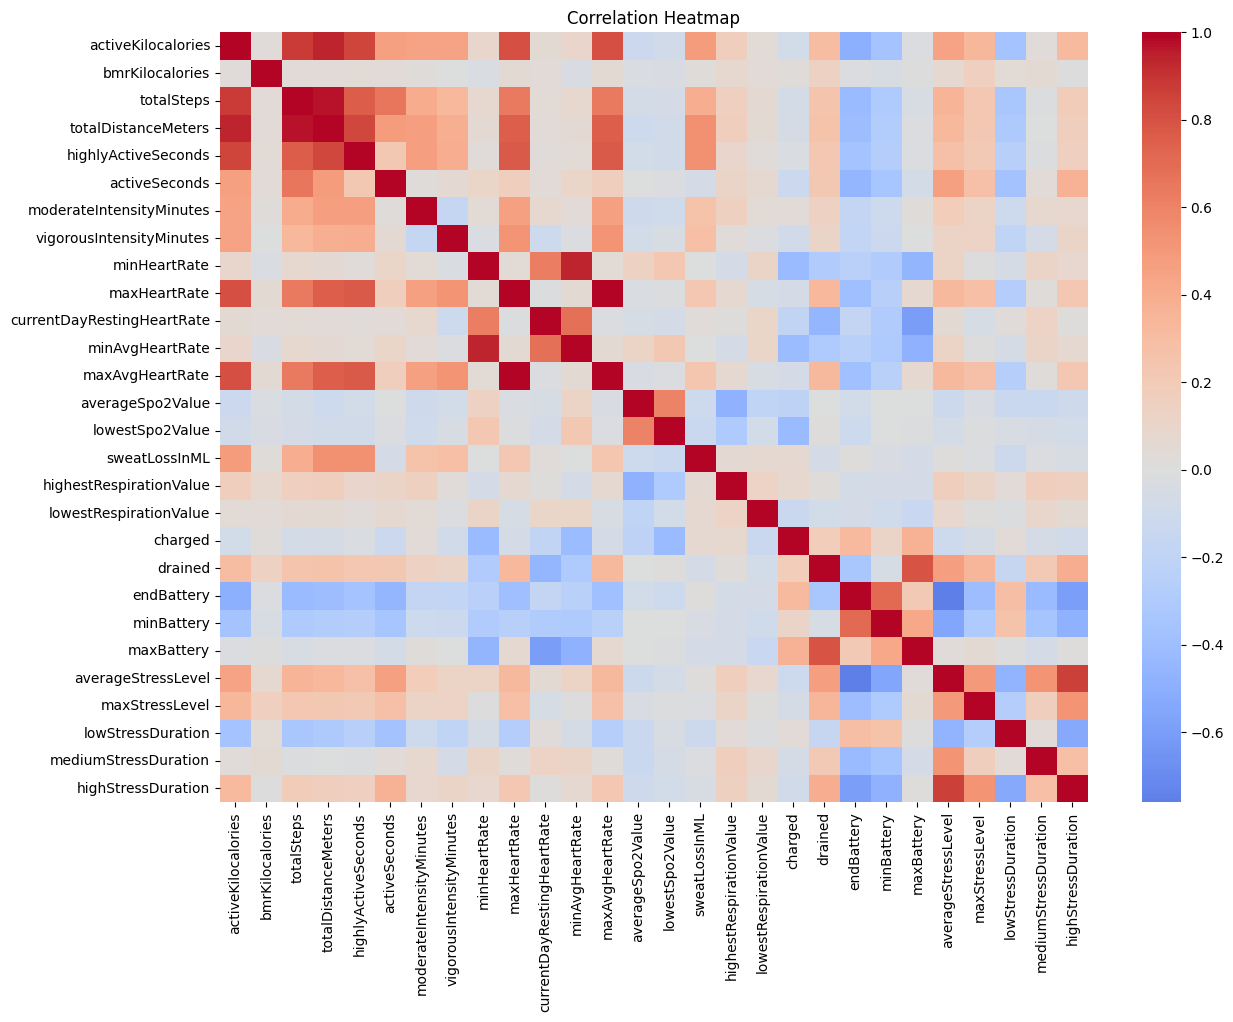

In [4]:
dailySummary_df = dailySummary_raw.copy()
numeric_cols = dailySummary_df.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(14,10))
sns.heatmap(
    dailySummary_df[numeric_cols].corr(),
    cmap="coolwarm",
    center=0,
    annot=False
)
plt.title("Correlation Heatmap")
plt.show()

In [16]:
from src.features.sleep import add_sleep_features
from scipy.stats import pearsonr
import numpy as np
import pandas as pd

# Align sleep + daily on calendarDate
daily = dailySummary_raw.copy()
sleep = add_sleep_features(sleep_raw)

daily["calendarDate"] = pd.to_datetime(daily["calendarDate"])
sleep["calendarDate"] = pd.to_datetime(sleep["calendarDate"])

merged = daily.merge(sleep, on="calendarDate", how="inner")

# Numeric daily features
daily_cols = merged[dailySummary_raw.select_dtypes(include=[np.number]).columns].columns

# Numeric sleep features
sleep_cols = merged[add_sleep_features(sleep_raw).select_dtypes(include=[np.number]).columns].columns

results = []

for s_col in sleep_cols:
    for d_col in daily_cols:

        x = merged[s_col].values.astype(float)
        y = merged[d_col].values.astype(float)

        # Remove NaN/inf pairs
        mask = np.isfinite(x) & np.isfinite(y)
        x_clean = x[mask]
        y_clean = y[mask]

        # Need at least 3 points
        if len(x_clean) < 3:
            continue

        # Skip constant arrays
        if np.nanstd(x_clean) == 0 or np.nanstd(y_clean) == 0:
            continue

        # Pearson correlation
        r, p = pearsonr(x_clean, y_clean)

        if p < 0.05:
            results.append((s_col, d_col, r, p))

# Print results
if not results:
    print("No significant sleep → daily correlations found.")
else:
    print("Significant Sleep → Daily Correlations (p < 0.05):\n")
    for s_col, d_col, r, p in sorted(results, key=lambda x: abs(x[2]), reverse=True):
        print(f"{s_col}  →  {d_col}   r={r:.3f}, p={p:.4f}")


Significant Sleep → Daily Correlations (p < 0.05):

lowestSPO2  →  lowestSpo2Value   r=0.908, p=0.0000
averageSPO2  →  averageSpo2Value   r=0.871, p=0.0000
avgSleepStress  →  maxBattery   r=-0.753, p=0.0000
averageHR  →  currentDayRestingHeartRate   r=0.743, p=0.0000
averageHR  →  maxBattery   r=-0.699, p=0.0000
recoveryScore  →  maxBattery   r=0.671, p=0.0000
avgSleepStress  →  drained   r=-0.620, p=0.0000
averageSPO2  →  lowestSpo2Value   r=0.601, p=0.0000
averageHR  →  minAvgHeartRate   r=0.597, p=0.0000
lowestSPO2  →  averageSpo2Value   r=0.590, p=0.0000
totalSleepSeconds  →  maxBattery   r=0.587, p=0.0000
sleep_hours  →  maxBattery   r=0.587, p=0.0000
lowestRespiration  →  lowestRespirationValue   r=0.587, p=0.0000
durationScore  →  maxBattery   r=0.573, p=0.0000
averageHR  →  minHeartRate   r=0.558, p=0.0000
avgSleepStress  →  currentDayRestingHeartRate   r=0.555, p=0.0000
overallScore  →  maxBattery   r=0.555, p=0.0000
averageHR  →  drained   r=-0.523, p=0.0000
hours_in_bed  →  

## How have my stats changed of the years?

Has my activity level changed over the years?